IMAGE SHAPE: (2571, 347)
PEAKS: [ 57 193 329]
BOUNDARIES: [  0  57 193 329 347]

COLUMN MEANS BEFORE
Column 0: 27.05
Column 1: 86.21
Column 2: 77.56
Column 3: 71.03

TARGET MEAN: 65.46

COLUMN MEANS AFTER
Column 0: 65.01
Column 1: 65.67
Column 2: 65.60
Column 3: 65.49

Saved: corrected_vertical.png


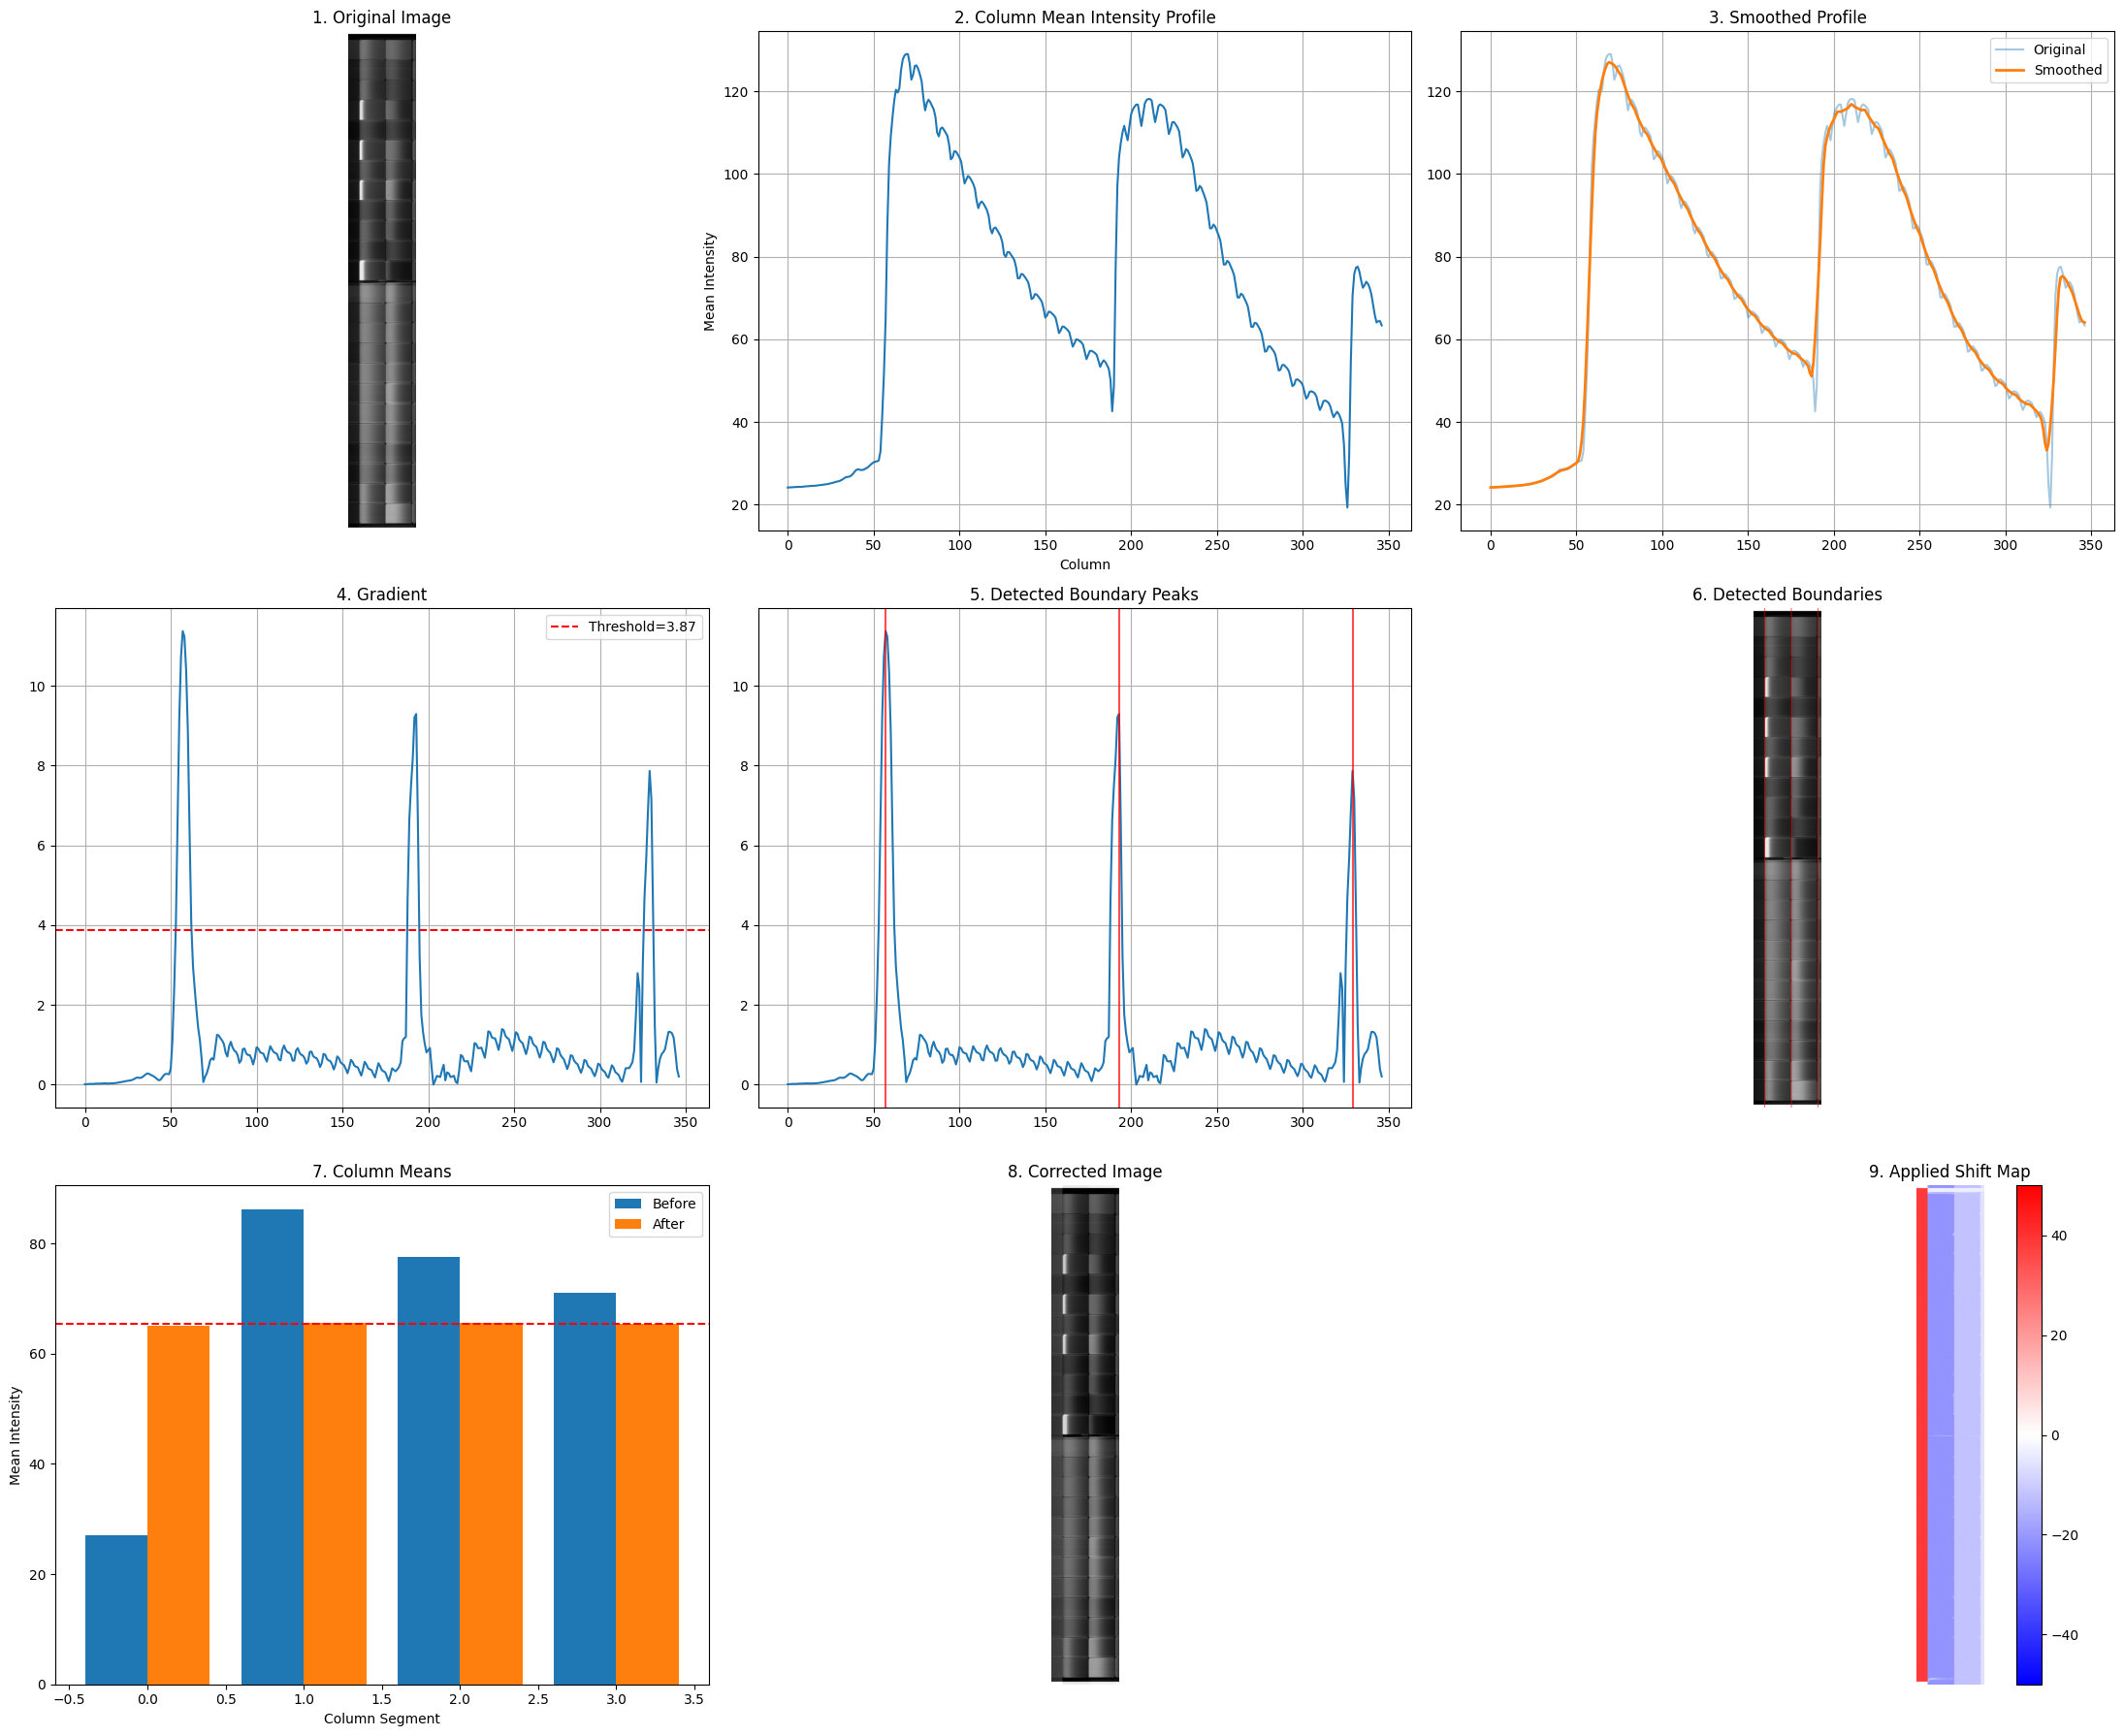

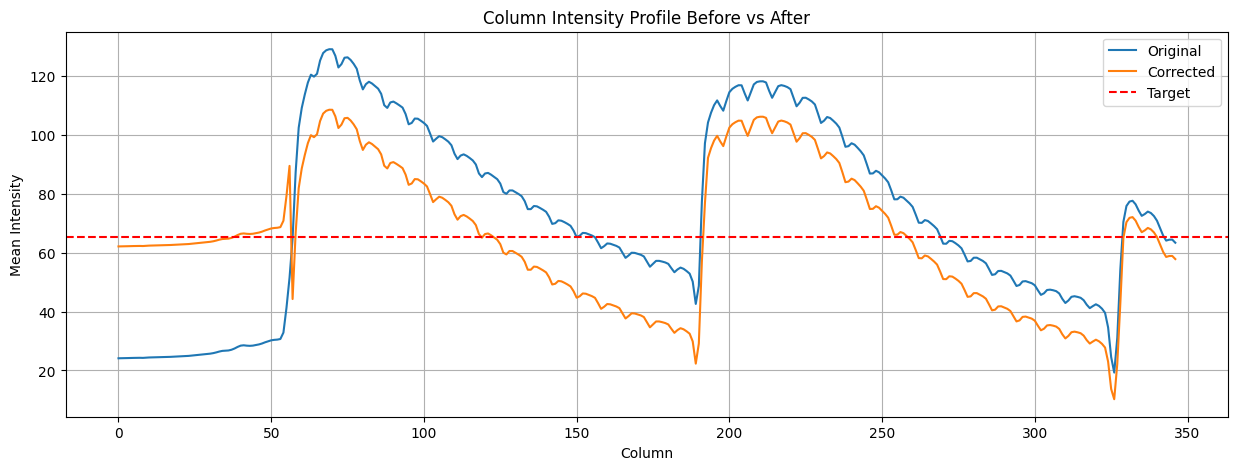

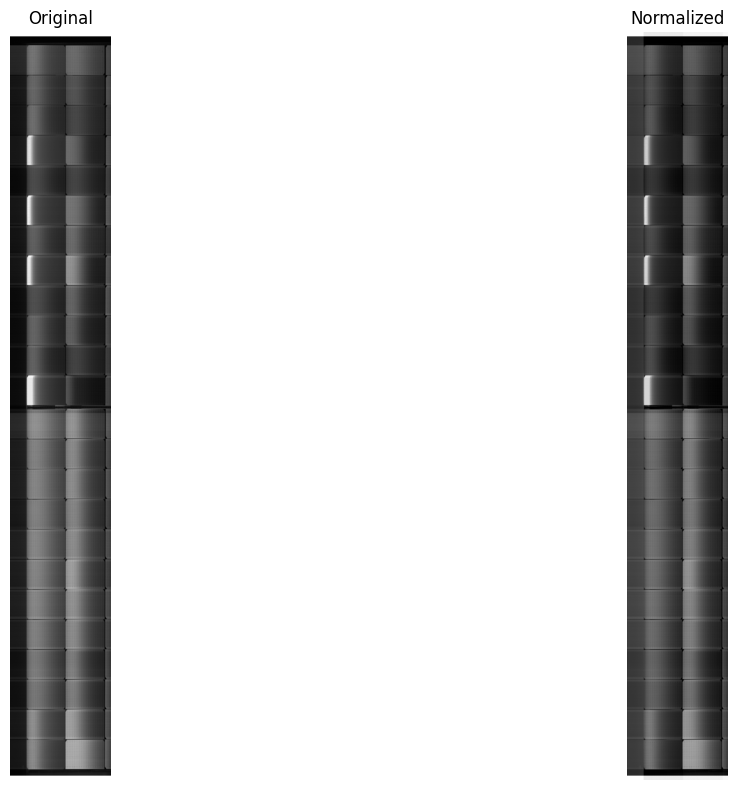

In [4]:
# ============================================================
# VERTICAL CELL / COLUMN INTENSITY NORMALIZATION
# FULL NOTEBOOK CELL WITH ALL INTERMEDIATE RESULTS
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import uniform_filter1d
from scipy.signal import find_peaks

# ------------------------------------------------------------
# INPUT
# ------------------------------------------------------------
IMAGE_PATH = "Output/Images1/4_strip_extracted/SEG_1.png"
OUTPUT_PATH = "corrected_vertical.png"

# ------------------------------------------------------------
# LOAD IMAGE
# ------------------------------------------------------------
img = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError(f"Cannot load image: {IMAGE_PATH}")

img = img.astype(np.float32)
h, w = img.shape

# ------------------------------------------------------------
# STEP 1 : COLUMN INTENSITY PROFILE
# ------------------------------------------------------------
profile = img.mean(axis=0)

# ------------------------------------------------------------
# STEP 2 : SMOOTH PROFILE
# ------------------------------------------------------------
smoothed = uniform_filter1d(profile, size=7)

# ------------------------------------------------------------
# STEP 3 : GRADIENT
# ------------------------------------------------------------
gradient = np.abs(np.gradient(smoothed))

# ------------------------------------------------------------
# STEP 4 : DETECT COLUMN BOUNDARIES
# ------------------------------------------------------------
threshold = gradient.mean() + 1.5 * gradient.std()

peaks, _ = find_peaks(
    gradient,
    height=threshold,
    distance=10
)

boundaries = np.concatenate([[0], peaks, [w]])

print("=" * 60)
print("IMAGE SHAPE:", img.shape)
print("PEAKS:", peaks)
print("BOUNDARIES:", boundaries)
print("=" * 60)

# ------------------------------------------------------------
# STEP 5 : COLUMN MEANS BEFORE
# ------------------------------------------------------------
cell_means = []

for i in range(len(boundaries) - 1):

    x0 = int(boundaries[i])
    x1 = int(boundaries[i + 1])

    mean_val = img[:, x0:x1].mean()

    cell_means.append(mean_val)

print("\nCOLUMN MEANS BEFORE")
for i, m in enumerate(cell_means):
    print(f"Column {i}: {m:.2f}")

# ------------------------------------------------------------
# STEP 6 : TARGET INTENSITY
# ------------------------------------------------------------
target_mean = np.mean(cell_means)

print("\nTARGET MEAN:", round(target_mean, 2))

# ------------------------------------------------------------
# STEP 7 : ADDITIVE NORMALIZATION
# ------------------------------------------------------------
corrected = img.copy()
shifts = []

for i in range(len(boundaries) - 1):

    x0 = int(boundaries[i])
    x1 = int(boundaries[i + 1])

    shift = target_mean - cell_means[i]
    shifts.append(shift)

    corrected[:, x0:x1] = np.clip(
        img[:, x0:x1] + shift,
        0,
        255
    )

# ------------------------------------------------------------
# STEP 8 : VERIFY
# ------------------------------------------------------------
new_means = []

for i in range(len(boundaries) - 1):

    x0 = int(boundaries[i])
    x1 = int(boundaries[i + 1])

    new_means.append(
        corrected[:, x0:x1].mean()
    )

print("\nCOLUMN MEANS AFTER")
for i, m in enumerate(new_means):
    print(f"Column {i}: {m:.2f}")

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------
cv2.imwrite(
    OUTPUT_PATH,
    corrected.astype(np.uint8)
)

print("\nSaved:", OUTPUT_PATH)

# ------------------------------------------------------------
# DIFFERENCE IMAGE
# ------------------------------------------------------------
diff = corrected - img

# ------------------------------------------------------------
# IMAGE WITH DETECTED BOUNDARIES
# ------------------------------------------------------------
boundary_img = cv2.cvtColor(
    img.astype(np.uint8),
    cv2.COLOR_GRAY2RGB
)

for b in boundaries[1:-1]:

    cv2.line(
        boundary_img,
        (int(b), 0),
        (int(b), h - 1),
        (255, 0, 0),
        2
    )

# ------------------------------------------------------------
# DISPLAY EVERYTHING
# ------------------------------------------------------------
fig = plt.figure(figsize=(22, 18))

# ------------------------------------------------------------
# ORIGINAL IMAGE
# ------------------------------------------------------------
plt.subplot(3,3,1)
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title("1. Original Image")
plt.axis("off")

# ------------------------------------------------------------
# COLUMN PROFILE
# ------------------------------------------------------------
plt.subplot(3,3,2)
plt.plot(profile)
plt.title("2. Column Mean Intensity Profile")
plt.xlabel("Column")
plt.ylabel("Mean Intensity")
plt.grid(True)

# ------------------------------------------------------------
# SMOOTHED PROFILE
# ------------------------------------------------------------
plt.subplot(3,3,3)
plt.plot(profile, alpha=0.4, label="Original")
plt.plot(smoothed, linewidth=2, label="Smoothed")
plt.title("3. Smoothed Profile")
plt.legend()
plt.grid(True)

# ------------------------------------------------------------
# GRADIENT
# ------------------------------------------------------------
plt.subplot(3,3,4)
plt.plot(gradient)

plt.axhline(
    threshold,
    color='red',
    linestyle='--',
    label=f'Threshold={threshold:.2f}'
)

plt.title("4. Gradient")
plt.legend()
plt.grid(True)

# ------------------------------------------------------------
# PEAKS
# ------------------------------------------------------------
plt.subplot(3,3,5)

plt.plot(gradient)

for p in peaks:
    plt.axvline(
        p,
        color='red',
        alpha=0.7
    )

plt.title("5. Detected Boundary Peaks")
plt.grid(True)

# ------------------------------------------------------------
# BOUNDARIES ON IMAGE
# ------------------------------------------------------------
plt.subplot(3,3,6)
plt.imshow(boundary_img)
plt.title("6. Detected Boundaries")
plt.axis("off")

# ------------------------------------------------------------
# COLUMN MEANS BEFORE / AFTER
# ------------------------------------------------------------
plt.subplot(3,3,7)

x = np.arange(len(cell_means))

plt.bar(
    x - 0.2,
    cell_means,
    width=0.4,
    label="Before"
)

plt.bar(
    x + 0.2,
    new_means,
    width=0.4,
    label="After"
)

plt.axhline(
    target_mean,
    color='red',
    linestyle='--'
)

plt.title("7. Column Means")
plt.xlabel("Column Segment")
plt.ylabel("Mean Intensity")
plt.legend()

# ------------------------------------------------------------
# CORRECTED IMAGE
# ------------------------------------------------------------
plt.subplot(3,3,8)
plt.imshow(
    corrected,
    cmap='gray',
    vmin=0,
    vmax=255
)
plt.title("8. Corrected Image")
plt.axis("off")

# ------------------------------------------------------------
# DIFFERENCE MAP
# ------------------------------------------------------------
plt.subplot(3,3,9)

im = plt.imshow(
    diff,
    cmap='bwr',
    vmin=-50,
    vmax=50
)

plt.title("9. Applied Shift Map")
plt.axis("off")
plt.colorbar(im)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# PROFILE COMPARISON
# ------------------------------------------------------------
plt.figure(figsize=(15,5))

plt.plot(
    img.mean(axis=0),
    label="Original"
)

plt.plot(
    corrected.mean(axis=0),
    label="Corrected"
)

plt.axhline(
    target_mean,
    color='red',
    linestyle='--',
    label='Target'
)

plt.title("Column Intensity Profile Before vs After")
plt.xlabel("Column")
plt.ylabel("Mean Intensity")
plt.grid(True)
plt.legend()
plt.show()

# ------------------------------------------------------------
# LARGE SIDE-BY-SIDE COMPARISON
# ------------------------------------------------------------
plt.figure(figsize=(18,8))

plt.subplot(1,2,1)
plt.imshow(
    img,
    cmap='gray',
    vmin=0,
    vmax=255
)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(
    corrected,
    cmap='gray',
    vmin=0,
    vmax=255
)
plt.title("Normalized")
plt.axis("off")

plt.tight_layout()
plt.show()

IMAGE SHAPE : (2571, 347)
BOUNDARIES  : [  0  57 193 329 347]
CELLS       : 4
Cell  0 | cols [   0-  57] | ref=  24.19 | before=[24.14-51.48] | after=[24.19-24.61]
Cell  1 | cols [  57- 193] | ref=  95.46 | before=[42.59-129.03] | after=[94.84-95.95]
Cell  2 | cols [ 193- 329] | ref= 108.63 | before=[19.29-118.14] | after=[107.58-108.68]
Cell  3 | cols [ 329- 347] | ref=  75.51 | before=[63.36-77.60] | after=[75.37-75.52]

Saved: corrected_columns.png


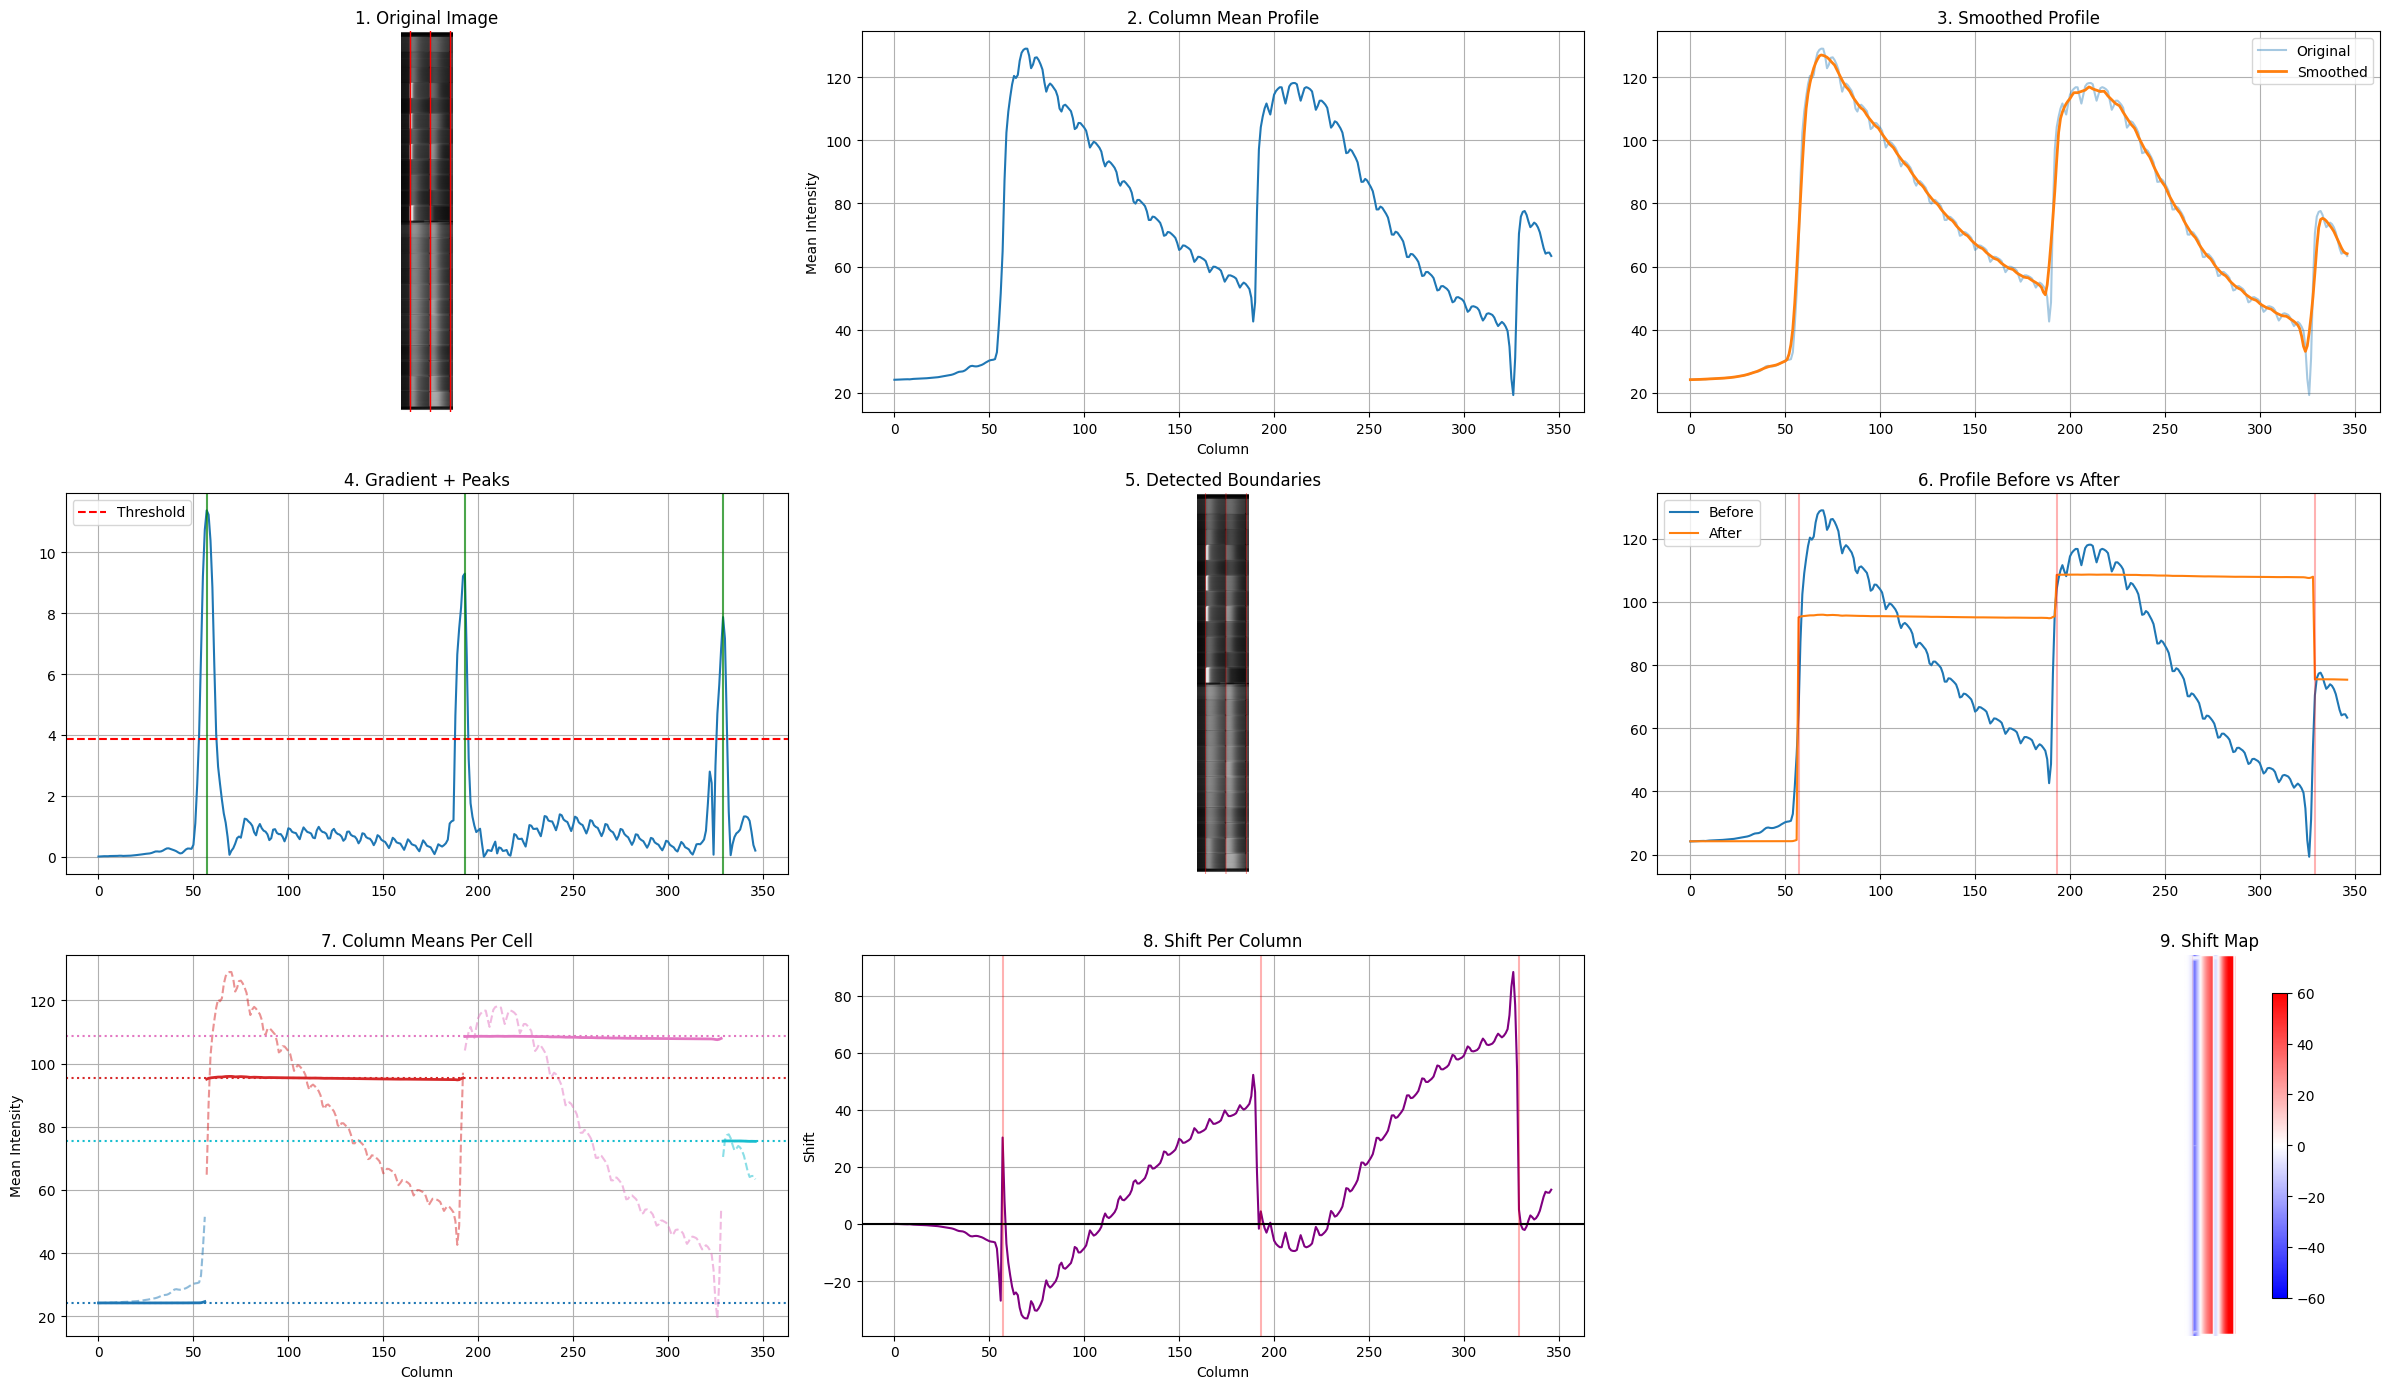

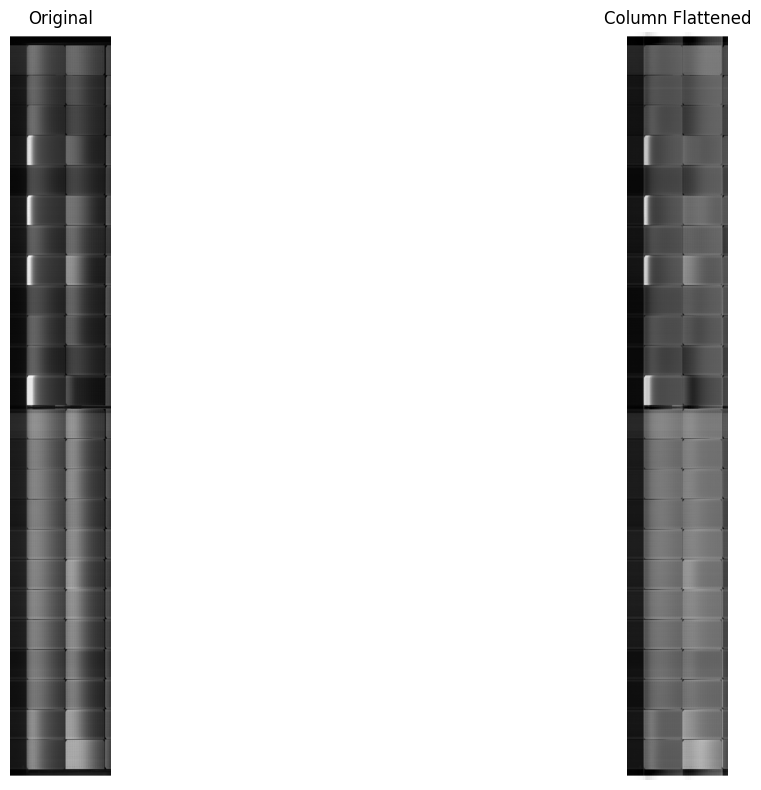

In [6]:
# ============================================================
# COLUMN-BY-COLUMN FLATTENING
# JUPYTER NOTEBOOK SINGLE CELL
# SHOWS ALL INTERMEDIATE RESULTS
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import uniform_filter1d
from scipy.signal import find_peaks

# ------------------------------------------------------------
# INPUT
# ------------------------------------------------------------
IMAGE_PATH = "Output/Images1/4_strip_extracted/SEG_1.png"
OUTPUT_PATH = "corrected_columns.png"
START_COLS = 5

# ------------------------------------------------------------
# LOAD IMAGE
# ------------------------------------------------------------
img = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError(f"Cannot load image: {IMAGE_PATH}")

img = img.astype(np.float32)

h, w = img.shape

# ------------------------------------------------------------
# STEP 1 : COLUMN PROFILE
# ------------------------------------------------------------
profile = img.mean(axis=0)

# ------------------------------------------------------------
# STEP 2 : SMOOTH PROFILE
# ------------------------------------------------------------
smoothed = uniform_filter1d(profile, size=7)

# ------------------------------------------------------------
# STEP 3 : GRADIENT
# ------------------------------------------------------------
gradient = np.abs(np.gradient(smoothed))

# ------------------------------------------------------------
# STEP 4 : DETECT BOUNDARIES
# ------------------------------------------------------------
threshold = gradient.mean() + 1.5 * gradient.std()

peaks, _ = find_peaks(
    gradient,
    height=threshold,
    distance=15
)

boundaries = np.sort(
    np.concatenate([[0], peaks, [w]])
)

n_cells = len(boundaries) - 1

print("=" * 70)
print("IMAGE SHAPE :", img.shape)
print("BOUNDARIES  :", boundaries)
print("CELLS       :", n_cells)
print("=" * 70)

# ------------------------------------------------------------
# STEP 5 : COLUMN FLATTENING
# ------------------------------------------------------------
corrected = img.copy()

cell_info = []

for i in range(n_cells):

    c0 = int(boundaries[i])
    c1 = int(boundaries[i + 1])

    cell_w = c1 - c0

    if cell_w < 2:
        continue

    ref_end = c0 + min(START_COLS, cell_w)

    ref_mean = img[:, c0:ref_end].mean()

    before_cols = []
    after_cols = []

    for c in range(c0, c1):

        col_mean = img[:, c].mean()

        shift = ref_mean - col_mean

        corrected[:, c] = np.clip(
            img[:, c] + shift,
            0,
            255
        )

        before_cols.append(col_mean)
        after_cols.append(
            corrected[:, c].mean()
        )

    cell_info.append({
        "idx": i,
        "c0": c0,
        "c1": c1,
        "ref": ref_mean,
        "before": before_cols,
        "after": after_cols
    })

    print(
        f"Cell {i:2d} | "
        f"cols [{c0:4d}-{c1:4d}] | "
        f"ref={ref_mean:7.2f} | "
        f"before=[{min(before_cols):.2f}-{max(before_cols):.2f}] | "
        f"after=[{min(after_cols):.2f}-{max(after_cols):.2f}]"
    )

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------
cv2.imwrite(
    OUTPUT_PATH,
    corrected.astype(np.uint8)
)

print("\nSaved:", OUTPUT_PATH)

# ------------------------------------------------------------
# PROFILES AFTER
# ------------------------------------------------------------
profile_after = corrected.mean(axis=0)

# ------------------------------------------------------------
# BOUNDARY IMAGE
# ------------------------------------------------------------
boundary_img = cv2.cvtColor(
    img.astype(np.uint8),
    cv2.COLOR_GRAY2RGB
)

for b in boundaries[1:-1]:

    cv2.line(
        boundary_img,
        (int(b), 0),
        (int(b), h - 1),
        (255, 0, 0),
        2
    )

# ------------------------------------------------------------
# SHIFT MAP
# ------------------------------------------------------------
shift_map = corrected - img

# ------------------------------------------------------------
# DISPLAY EVERYTHING
# ------------------------------------------------------------
fig = plt.figure(figsize=(24, 14))

# ------------------------------------------------------------
# ORIGINAL IMAGE
# ------------------------------------------------------------
ax1 = fig.add_subplot(3,3,1)

ax1.imshow(
    img,
    cmap="gray",
    vmin=0,
    vmax=255
)

for b in boundaries[1:-1]:
    ax1.axvline(b, color='red', lw=1)

ax1.set_title("1. Original Image")
ax1.axis("off")

# ------------------------------------------------------------
# COLUMN PROFILE
# ------------------------------------------------------------
ax2 = fig.add_subplot(3,3,2)

ax2.plot(profile)

ax2.set_title("2. Column Mean Profile")
ax2.set_xlabel("Column")
ax2.set_ylabel("Mean Intensity")
ax2.grid(True)

# ------------------------------------------------------------
# SMOOTHED PROFILE
# ------------------------------------------------------------
ax3 = fig.add_subplot(3,3,3)

ax3.plot(
    profile,
    alpha=0.4,
    label="Original"
)

ax3.plot(
    smoothed,
    linewidth=2,
    label="Smoothed"
)

ax3.legend()
ax3.grid(True)
ax3.set_title("3. Smoothed Profile")

# ------------------------------------------------------------
# GRADIENT
# ------------------------------------------------------------
ax4 = fig.add_subplot(3,3,4)

ax4.plot(gradient)

ax4.axhline(
    threshold,
    color='red',
    linestyle='--',
    label='Threshold'
)

for p in peaks:
    ax4.axvline(
        p,
        color='green',
        alpha=0.7
    )

ax4.legend()
ax4.grid(True)
ax4.set_title("4. Gradient + Peaks")

# ------------------------------------------------------------
# DETECTED BOUNDARIES
# ------------------------------------------------------------
ax5 = fig.add_subplot(3,3,5)

ax5.imshow(boundary_img)

ax5.set_title("5. Detected Boundaries")
ax5.axis("off")

# ------------------------------------------------------------
# BEFORE / AFTER PROFILE
# ------------------------------------------------------------
ax6 = fig.add_subplot(3,3,6)

ax6.plot(
    profile,
    label="Before"
)

ax6.plot(
    profile_after,
    label="After"
)

for b in boundaries[1:-1]:
    ax6.axvline(
        b,
        color='red',
        alpha=0.3
    )

ax6.legend()
ax6.grid(True)
ax6.set_title("6. Profile Before vs After")

# ------------------------------------------------------------
# PER-CELL COLUMN DETAILS
# ------------------------------------------------------------
ax7 = fig.add_subplot(3,3,7)

colors = plt.cm.tab10(
    np.linspace(0, 1, max(1, n_cells))
)

for cell in cell_info:

    cols = np.arange(
        cell["c0"],
        cell["c1"]
    )

    ax7.plot(
        cols,
        cell["before"],
        '--',
        alpha=0.5,
        color=colors[cell["idx"] % 10]
    )

    ax7.plot(
        cols,
        cell["after"],
        linewidth=2,
        color=colors[cell["idx"] % 10]
    )

    ax7.axhline(
        cell["ref"],
        linestyle=':',
        color=colors[cell["idx"] % 10]
    )

ax7.set_title("7. Column Means Per Cell")
ax7.set_xlabel("Column")
ax7.set_ylabel("Mean Intensity")
ax7.grid(True)

# ------------------------------------------------------------
# SHIFTS APPLIED
# ------------------------------------------------------------
ax8 = fig.add_subplot(3,3,8)

all_shifts = profile_after - profile

ax8.plot(
    all_shifts,
    color='purple'
)

ax8.axhline(
    0,
    color='black'
)

for b in boundaries[1:-1]:
    ax8.axvline(
        b,
        color='red',
        alpha=0.3
    )

ax8.set_title("8. Shift Per Column")
ax8.set_xlabel("Column")
ax8.set_ylabel("Shift")
ax8.grid(True)

# ------------------------------------------------------------
# SHIFT MAP
# ------------------------------------------------------------
ax9 = fig.add_subplot(3,3,9)

im = ax9.imshow(
    shift_map,
    cmap='bwr',
    vmin=-60,
    vmax=60
)

ax9.set_title("9. Shift Map")
ax9.axis("off")

plt.colorbar(
    im,
    ax=ax9,
    shrink=0.8
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# LARGE BEFORE / AFTER
# ------------------------------------------------------------
plt.figure(figsize=(18,8))

plt.subplot(1,2,1)

plt.imshow(
    img,
    cmap='gray',
    vmin=0,
    vmax=255
)

plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)

plt.imshow(
    corrected,
    cmap='gray',
    vmin=0,
    vmax=255
)

plt.title("Column Flattened")
plt.axis("off")

plt.tight_layout()
plt.show()